# full_assets_df Analysis

This notebook focuses only on `full_assets_df`.

It keeps the setup and analysis tight:
- load the dataframe
- keep the term guide close by
- analyze the asset hierarchy programmatically
- compare super classes using grouped averages
- compare asset classes within each super class
- keep supplementary examples at the bottom


## Step 1: Setup

Run this first.


In [ ]:
import sys
from pathlib import Path

import pandas as pd
from IPython.core.getipython import get_ipython
from IPython.display import HTML, Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "backend" / "soc_api" / "__init__.py").exists():
            return candidate
    raise RuntimeError("Could not find the project root. Start the notebook from somewhere inside this repo.")


PROJECT_ROOT = find_project_root(Path.cwd())
BACKEND_DIR = PROJECT_ROOT / "backend"
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from soc_api import *

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

import plotly.express as px

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True



def display_plotly_figure(fig):
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))


print("Project root detected.")
print("PLOTLY_RENDER_MODE = inline_html")


## Step 2: Load `full_assets_df`

This is the main one-row-per-asset table.


In [ ]:
full_assets_df = get_full_assets_df()


## Step 3: Term Guide

This duplicates the key interpretation table for the asset dataframe.

The display below is styled so the text wraps cleanly instead of getting visually truncated.


In [ ]:
assets_term_guide_df = pd.DataFrame(
    [
        {"Term": "ticker", "Plain-English meaning": "Short market symbol for an asset", "How to read the values": "Identifier only; not a measurement", "Status": "verified"},
        {"Term": "super_class", "Plain-English meaning": "Broad grouping such as Equity or Fixed Income", "How to read the values": "Good for high-level grouping", "Status": "verified"},
        {"Term": "asset_class", "Plain-English meaning": "More specific category inside the broad grouping", "How to read the values": "Good for more detailed grouping", "Status": "verified"},
        {"Term": "currency", "Plain-English meaning": "Money unit used for the asset", "How to read the values": "USD and JMD are currencies, not risk levels", "Status": "verified"},
        {"Term": "total_expected_return", "Plain-English meaning": "Estimated total return over a year", "How to read the values": "Model estimate; not a promise", "Status": "verified"},
        {"Term": "income_yield_ann", "Plain-English meaning": "Income-related yield over one year", "How to read the values": "Higher values mean more expected income contribution", "Status": "verified"},
        {"Term": "volatility_ann", "Plain-English meaning": "Annualized variability of returns", "How to read the values": "Higher values usually mean wider swings and more uncertainty", "Status": "verified"},
        {"Term": "semi_deviation_ann", "Plain-English meaning": "Downside-focused version of volatility", "How to read the values": "Focuses more on downside moves than upside moves", "Status": "inferred"},
        {"Term": "skewness", "Plain-English meaning": "Asymmetry of the return distribution", "How to read the values": "Sign shows which side has the longer tail", "Status": "verified"},
        {"Term": "excess_kurtosis", "Plain-English meaning": "Tail-heaviness relative to a normal distribution", "How to read the values": "Larger values suggest more extreme outcomes", "Status": "verified"},
        {"Term": "modified_duration", "Plain-English meaning": "Bond sensitivity to interest-rate changes", "How to read the values": "Larger values usually mean more rate sensitivity", "Status": "verified"},
        {"Term": "rate_beta", "Plain-English meaning": "Sensitivity score for rate moves", "How to read the values": "Read as an interest-rate sensitivity indicator unless the project gives a formula later", "Status": "inferred"},
        {"Term": "inflation_beta", "Plain-English meaning": "Sensitivity score for inflation changes", "How to read the values": "Read as an inflation sensitivity indicator", "Status": "inferred"},
        {"Term": "fx_beta", "Plain-English meaning": "Sensitivity score for foreign-exchange moves", "How to read the values": "Read as a currency sensitivity indicator", "Status": "inferred"},
        {"Term": "expense_ratio_ann", "Plain-English meaning": "Annual cost ratio charged by a fund-like product", "How to read the values": "Higher values mean more annual cost drag", "Status": "verified"},
    ]
)

assets_term_guide_styler = (
    assets_term_guide_df.style
    .hide(axis="index")
    .set_properties(subset=["Plain-English meaning", "How to read the values"], **{"white-space": "normal", "text-align": "left"})
    .set_properties(subset=["Term", "Status"], **{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("vertical-align", "top"), ("max-width", "420px")]},
    ])
)

display(assets_term_guide_styler)


Term,Plain-English meaning,How to read the values,Status
ticker,Short market symbol for an asset,Identifier only; not a measurement,verified
super_class,Broad grouping such as Equity or Fixed Income,Good for high-level grouping,verified
asset_class,More specific category inside the broad grouping,Good for more detailed grouping,verified
currency,Money unit used for the asset,"USD and JMD are currencies, not risk levels",verified
total_expected_return,Estimated total return over a year,Model estimate; not a promise,verified
income_yield_ann,Income-related yield over one year,Higher values mean more expected income contribution,verified
volatility_ann,Annualized variability of returns,Higher values usually mean wider swings and more uncertainty,verified
semi_deviation_ann,Downside-focused version of volatility,Focuses more on downside moves than upside moves,inferred
skewness,Asymmetry of the return distribution,Sign shows which side has the longer tail,verified
excess_kurtosis,Tail-heaviness relative to a normal distribution,Larger values suggest more extreme outcomes,verified


## Step 4: Asset Tree

This is a programmatic hierarchy view built from the dataframe itself.

In this dataset, the useful hierarchy is:
- `super_class` -> `asset_class` -> `ticker`

This section now gives you three views of that hierarchy:
- an interactive treemap
- a grouped table
- a markdown tree with the exact tickers

Because all three are built from `full_assets_df`, they update automatically if the dataframe changes.


In [ ]:
asset_tree_chart_df = full_assets_df.reset_index()[["ticker", "super_class", "asset_class"]].copy()
asset_tree_chart_df["value"] = 1

asset_tree_df = (
    asset_tree_chart_df.groupby(["super_class", "asset_class"], sort=False, as_index=False)
    .agg(
        ticker_count=("ticker", "size"),
        tickers=("ticker", lambda s: ", ".join(s.tolist())),
    )
)

asset_class_display_map = {
    "Short Government Bonds": "Short Gov Bonds",
    "Long Government Bonds": "Long Gov Bonds",
    "Alternative Investments": "Alt Investments",
    "Domestic Defensive Equity": "Defensive Equity",
    "Domestic Cyclical Equity": "Cyclical Equity",
    "Domestic Financial Equity": "Financial Equity",
    "Emerging Market Equity": "Emerging Mkts",
}

asset_tree_df["asset_class_display"] = asset_tree_df["asset_class"].map(asset_class_display_map).fillna(asset_tree_df["asset_class"])

asset_tree_df


,super_class,asset_class,ticker_count,tickers,asset_class_display
0,Equity,Emerging Market Equity,3,"BQB, CQOAC, EMWB",Emerging Mkts
1,Fixed Income,Short Government Bonds,2,"CWPU, PVAU",Short Gov Bonds
2,Fixed Income,Corporate Bonds,2,"DTOT, IRKXL",Corporate Bonds
3,Equity,Domestic Defensive Equity,3,"GGOC, PDTOU, XPMCJ",Defensive Equity
4,Fund,Alternative Investments,1,IGRIG,Alt Investments
5,Equity,Domestic Cyclical Equity,3,"IZQLN, MBTTD, YTR",Cyclical Equity
6,Fixed Income,Long Government Bonds,2,"JFG, QPESE",Long Gov Bonds
7,Equity,Domestic Financial Equity,3,"KBJZN, TIHE, XKFZ",Financial Equity
8,Equity,Global Tech Equity,3,"MOSWO, RJK, WBG",Global Tech Equity
9,Cash,JMD T-Bill,1,TBILLJMD,JMD T-Bill


### Treemap View

This treemap is intentionally simplified to `super_class -> asset_class` so the text stays readable.

Some long asset-class names are shortened on the chart only. Hover still shows the full asset-class name and the exact tickers.


In [ ]:
treemap_fig = px.treemap(
    asset_tree_df,
    path=["super_class", "asset_class_display"],
    values="ticker_count",
    color="super_class",
    custom_data=["asset_class", "tickers"],
    title="Asset Hierarchy Treemap",
)

treemap_fig.update_traces(
    texttemplate="<b>%{label}</b><br>%{value}",
    textfont=dict(size=16),
    hovertemplate="<b>%{customdata[0]}</b><br>Ticker count: %{value}<br>Tickers: %{customdata[1]}<extra></extra>",
)
treemap_fig.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
    height=780,
    uniformtext=dict(minsize=12, mode="show"),
)
display_plotly_figure(treemap_fig)


### Markdown Tree View

Use this if you want the hierarchy in plain text with the exact tickers listed under each branch.


In [ ]:
asset_tree_lines = []
for super_class, group in asset_tree_df.groupby("super_class", sort=False):
    asset_tree_lines.append(f"- **{super_class}**")
    for _, row in group.iterrows():
        asset_tree_lines.append(f"  - {row['asset_class']} ({row['ticker_count']}): {row['tickers']}")

display(Markdown("\n".join(asset_tree_lines)))


- **Equity**
  - Emerging Market Equity (3): BQB, CQOAC, EMWB
  - Domestic Defensive Equity (3): GGOC, PDTOU, XPMCJ
  - Domestic Cyclical Equity (3): IZQLN, MBTTD, YTR
  - Domestic Financial Equity (3): KBJZN, TIHE, XKFZ
  - Global Tech Equity (3): MOSWO, RJK, WBG
- **Fixed Income**
  - Short Government Bonds (2): CWPU, PVAU
  - Corporate Bonds (2): DTOT, IRKXL
  - Long Government Bonds (2): JFG, QPESE
- **Fund**
  - Alternative Investments (1): IGRIG
  - Real Estate Fund (1): XEAK
- **Cash**
  - JMD T-Bill (1): TBILLJMD
  - USD T-Bill (1): TBILLUSD

## Step 5: Focus of This Notebook

This notebook is meant to be the interpretation and analysis version of `full_assets_df`.

The generic dataframe verification checks such as `.shape`, `.head()`, `.dtypes`, missing-value checks, and basic `.describe()` summaries live in `api_tryouts.ipynb` so this notebook can stay focused on structure, grouping, and interpretation.


## Step 6: Super Class Feature Averages

This section averages every numeric feature in `full_assets_df` by `super_class`.

Read this carefully:
- Each row is one `super_class`.
- Each column is a numeric feature from the asset dataset.
- Use the grouped mean tables for the full view, then the separate bar charts for the three main portfolio features.


In [ ]:
numeric_feature_columns = full_assets_df.select_dtypes(include="number").columns.tolist()

super_class_feature_means_df = full_assets_df.groupby("super_class")[numeric_feature_columns].mean()
super_class_counts_s = full_assets_df.groupby("super_class").size().rename("asset_count")

super_class_feature_means_df.round(4)


,total_expected_return,income_yield_ann,volatility_ann,semi_deviation_ann,skewness,excess_kurtosis,modified_duration,rate_beta,inflation_beta,fx_beta,expense_ratio_ann
super_class,,,,,,,,,,,
Cash,0.0442,0.0384,0.0097,0.0072,-0.0491,0.1151,0.0000,0.4448,-0.1608,0.5112,0.0000
Equity,0.1319,0.0140,0.2104,0.1855,-0.4763,2.3095,0.0000,-0.8538,0.0890,0.4193,0.0000
Fixed Income,0.0786,0.0786,0.0762,0.0626,-0.0746,1.1982,4.6538,-4.6472,-0.7023,0.0000,0.0000
Fund,0.1158,0.0488,0.1570,0.1170,-0.2278,1.6479,1.3582,-1.4424,0.4557,0.1040,0.0166


In [ ]:
super_class_counts_s


super_class
Cash             2
Equity          15
Fixed Income     6
Fund             2
Name: asset_count, dtype: int64

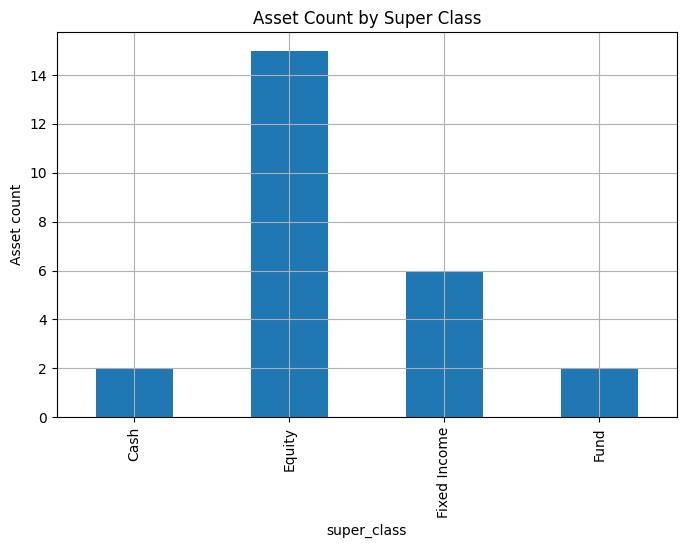

In [ ]:
super_class_counts_s.plot(kind="bar", title="Asset Count by Super Class")
plt.ylabel("Asset count")
plt.xlabel("super_class")
plt.show()


In [ ]:
currency_counts_s = full_assets_df.groupby("currency").size().rename("asset_count")

currency_counts_s


currency
JMD        17
JMD,USD     1
USD         7
Name: asset_count, dtype: int64

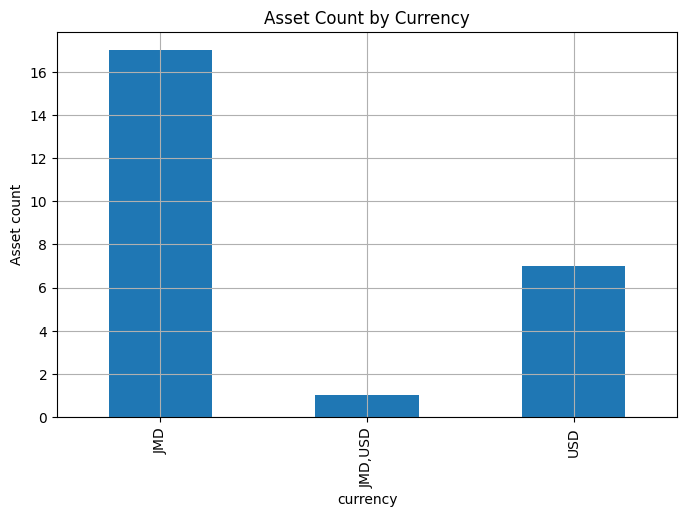

In [ ]:
currency_counts_s.plot(kind="bar", title="Asset Count by Currency")
plt.ylabel("Asset count")
plt.xlabel("currency")
plt.show()


In [ ]:
super_class_feature_means_df.T.round(4)


super_class,Cash,Equity,Fixed Income,Fund
total_expected_return,0.0442,0.1319,0.0786,0.1158
income_yield_ann,0.0384,0.0140,0.0786,0.0488
volatility_ann,0.0097,0.2104,0.0762,0.1570
semi_deviation_ann,0.0072,0.1855,0.0626,0.1170
skewness,-0.0491,-0.4763,-0.0746,-0.2278
excess_kurtosis,0.1151,2.3095,1.1982,1.6479
modified_duration,0.0000,0.0000,4.6538,1.3582
rate_beta,0.4448,-0.8538,-4.6472,-1.4424
inflation_beta,-0.1608,0.0890,-0.7023,0.4557
fx_beta,0.5112,0.4193,0.0000,0.1040


### Feature-Specific Bar Charts

These keep the three main portfolio features separated so each chart is easier to read.

Plain-English guide:
- `total_expected_return`: the model's estimate of the total gain over a year. If you invested `$100` and this was `10%`, think roughly `$10` total gain.
- `income_yield_ann`: the part that is paid to you while you hold the asset. If you invested `$100` and this was `4%`, think roughly `$4` paid out over the year. If this is `0`, the practical reading is that the asset is not expected to meaningfully pay income while you hold it.
- `volatility_ann`: how bumpy the ride is. Higher values usually mean the asset's value swings around more.

Useful shortcut:
- the gap between `total_expected_return` and `income_yield_ann` is roughly the part expected to come from the asset price changing rather than money paid to you directly.
- none of these are guarantees; they are model-based estimates for comparison.


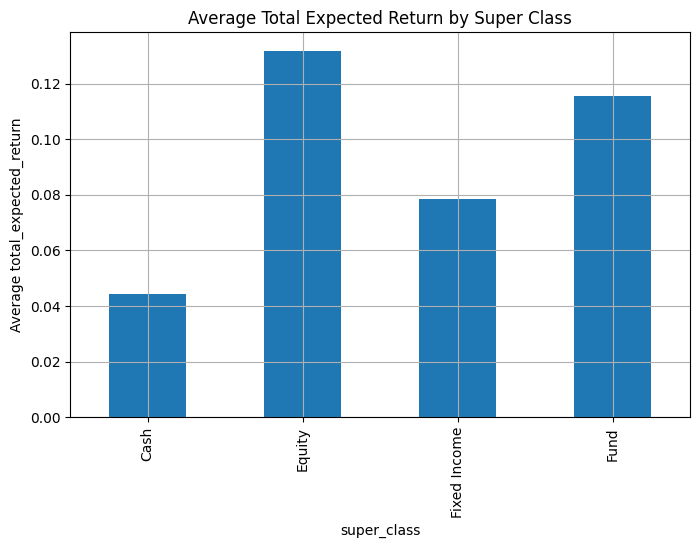

In [ ]:
super_class_feature_means_df["total_expected_return"].plot(
    kind="bar",
    title="Average Total Expected Return by Super Class",
)
plt.ylabel("Average total_expected_return")
plt.xlabel("super_class")
plt.show()


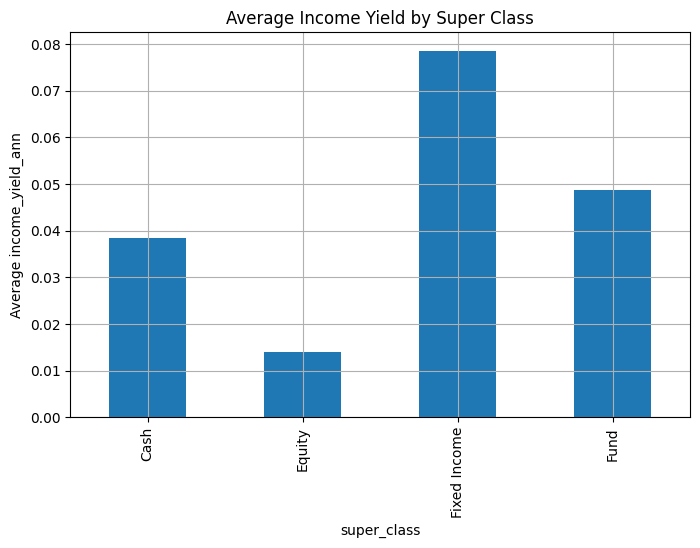

In [ ]:
super_class_feature_means_df["income_yield_ann"].plot(
    kind="bar",
    title="Average Income Yield by Super Class",
)
plt.ylabel("Average income_yield_ann")
plt.xlabel("super_class")
plt.show()


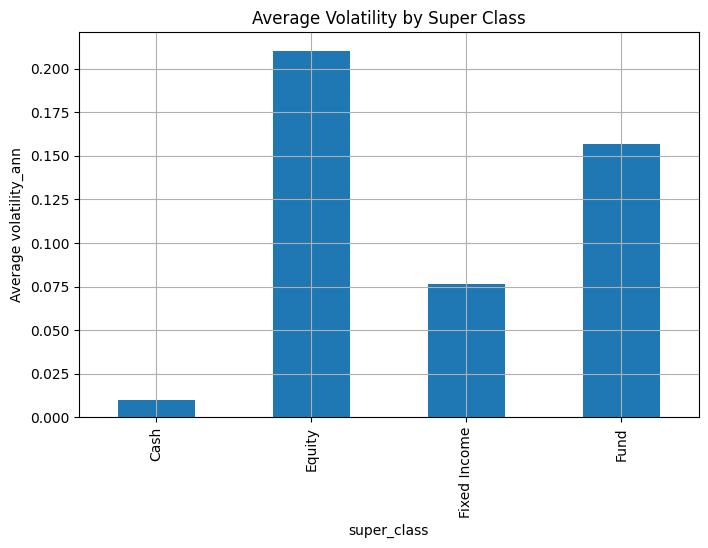

In [ ]:
super_class_feature_means_df["volatility_ann"].plot(
    kind="bar",
    title="Average Volatility by Super Class",
)
plt.ylabel("Average volatility_ann")
plt.xlabel("super_class")
plt.show()


## Step 7: Asset Class Feature Averages Within Each Super Class

This section keeps the lower-level comparison inside each `super_class`.

That matters because comparing all `asset_class` values across the whole dataset can mix categories that do not belong to the same top-level bucket. Here, each chart only compares sibling `asset_class` values inside one `super_class`.


In [ ]:
asset_class_within_super_class_feature_means_df = (
    full_assets_df.groupby(["super_class", "asset_class"])[numeric_feature_columns].mean()
)
asset_class_counts_s = full_assets_df.groupby("asset_class").size().rename("asset_count")

asset_class_within_super_class_feature_means_df.round(4)


total_expected_return  income_yield_ann  volatility_ann  semi_deviation_ann  skewness  \
super_class  asset_class                                                                                                        
Cash         JMD T-Bill                                0.0490            0.0375          0.0123              0.0088   -0.0532   
             USD T-Bill                                0.0394            0.0394          0.0071              0.0055   -0.0450   
Equity       Domestic Cyclical Equity                  0.1322            0.0036          0.1963              0.1766   -0.6285   
             Domestic Defensive Equity                 0.1077            0.0523          0.1618              0.1466   -0.2419   
             Domestic Financial Equity                 0.1221            0.0141          0.1885              0.1588   -0.2927   
             Emerging Market Equity                    0.1439            0.0000          0.2327              0.2105   -0.5651   
             Global Tech Equity                        0.1538            0.0000          0.2729              0.2351   -0.6531   
Fixed Income Corporate Bonds                           0.0952            0.0952          0.1025              0.0836   -0.3204   
             Long Government Bonds                     0.0819            0.0819          0.0960              0.0859    0.0121   
             Short Government Bonds                    0.0588            0.0588          0.0300              0.0185    0.0846   
Fund         Alternative Investments                   0.1182            0.0252          0.1364              0.1014   -0.0985   
             Real Estate Fund                          0.1133            0.0724          0.1777              0.1325   -0.3571   

                                        excess_kurtosis  modified_duration  rate_beta  inflation_beta  fx_beta  expense_ratio_ann  
super_class  asset_class                                                                                                           
Cash         JMD T-Bill                          0.0780             0.0000     0.7599         -0.1798   0.0000             0.0000  
             USD T-Bill                          0.1521             0.0000     0.1296         -0.1418   1.0224             0.0000  
Equity       Domestic Cyclical Equity            2.2681             0.0000    -0.0080          0.4123   0.0000             0.0000  
             Domestic Defensive Equity           1.4070             0.0000    -1.4847          0.1813   0.0000             0.0000  
             Domestic Financial Equity           1.6311             0.0000     0.6549          0.2546   0.0000             0.0000  
             Emerging Market Equity              3.3213             0.0000    -1.5140          0.2744   1.0722             0.0000  
             Global Tech Equity                  2.9201             0.0000    -1.9173         -0.6776   1.0245             0.0000  
Fixed Income Corporate Bonds                     1.7910             4.9413    -4.6106         -0.8789   0.0000             0.0000  
             Long Government Bonds               1.2671             7.6644    -7.8065         -0.7984   0.0000             0.0000  
             Short Government Bonds              0.5364             1.3558    -1.5246         -0.4296   0.0000             0.0000  
Fund         Alternative Investments             1.4272             2.7163    -1.8297          0.4029   0.2081             0.0177  
             Real Estate Fund                    1.8686             0.0000    -1.0552          0.5085   0.0000             0.0154

In [ ]:
asset_class_counts_s


asset_class
Alternative Investments      1
Corporate Bonds              2
Domestic Cyclical Equity     3
Domestic Defensive Equity    3
Domestic Financial Equity    3
Emerging Market Equity       3
Global Tech Equity           3
JMD T-Bill                   1
Long Government Bonds        2
Real Estate Fund             1
Short Government Bonds       2
USD T-Bill                   1
Name: asset_count, dtype: int64

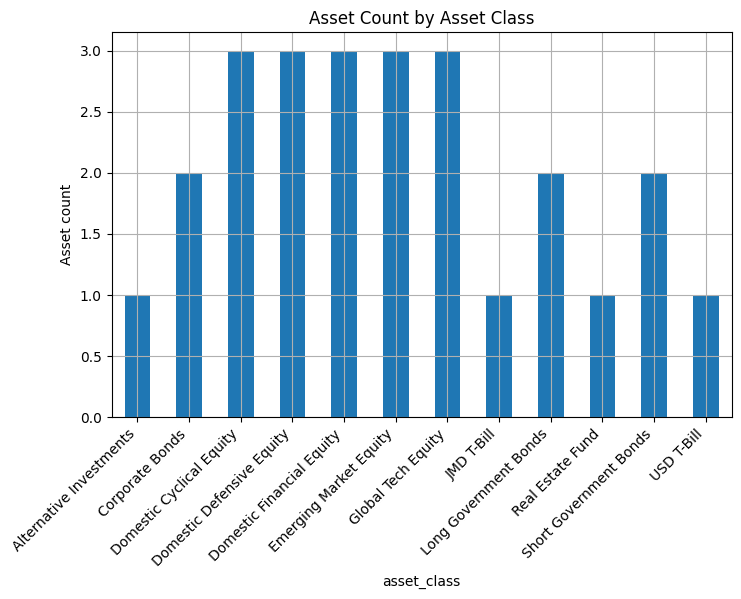

In [ ]:
asset_class_counts_s.plot(kind="bar", title="Asset Count by Asset Class")
plt.ylabel("Asset count")
plt.xlabel("asset_class")
plt.xticks(rotation=45, ha="right")
plt.show()


In [ ]:
asset_class_within_super_class_feature_means_df[[
    "total_expected_return",
    "income_yield_ann",
    "volatility_ann",
]].round(4)


total_expected_return  income_yield_ann  volatility_ann
super_class  asset_class                                                                       
Cash         JMD T-Bill                                0.0490            0.0375          0.0123
             USD T-Bill                                0.0394            0.0394          0.0071
Equity       Domestic Cyclical Equity                  0.1322            0.0036          0.1963
             Domestic Defensive Equity                 0.1077            0.0523          0.1618
             Domestic Financial Equity                 0.1221            0.0141          0.1885
             Emerging Market Equity                    0.1439            0.0000          0.2327
             Global Tech Equity                        0.1538            0.0000          0.2729
Fixed Income Corporate Bonds                           0.0952            0.0952          0.1025
             Long Government Bonds                     0.0819            0.0819          0.0960
             Short Government Bonds                    0.0588            0.0588          0.0300
Fund         Alternative Investments                   0.1182            0.0252          0.1364
             Real Estate Fund                          0.1133            0.0724          0.1777

### Feature-Specific Bar Charts Within Each Super Class

Each figure below is limited to one `super_class`, so the bars only compare the relevant `asset_class` values inside that branch.

Use the same reading rule here:
- `total_expected_return` = overall expected gain
- `income_yield_ann` = money paid to you while holding it. If it is `0`, read that as no meaningful income payout in this dataset.
- `volatility_ann` = how much the value tends to swing around

The count chart above matters because some `asset_class` groups have fewer assets than others, so their averages are based on less data.


#### Equity

,total_expected_return,income_yield_ann,volatility_ann
asset_class,,,
Domestic Cyclical Equity,0.1322,0.0036,0.1963
Domestic Defensive Equity,0.1077,0.0523,0.1618
Domestic Financial Equity,0.1221,0.0141,0.1885
Emerging Market Equity,0.1439,0.0000,0.2327
Global Tech Equity,0.1538,0.0000,0.2729


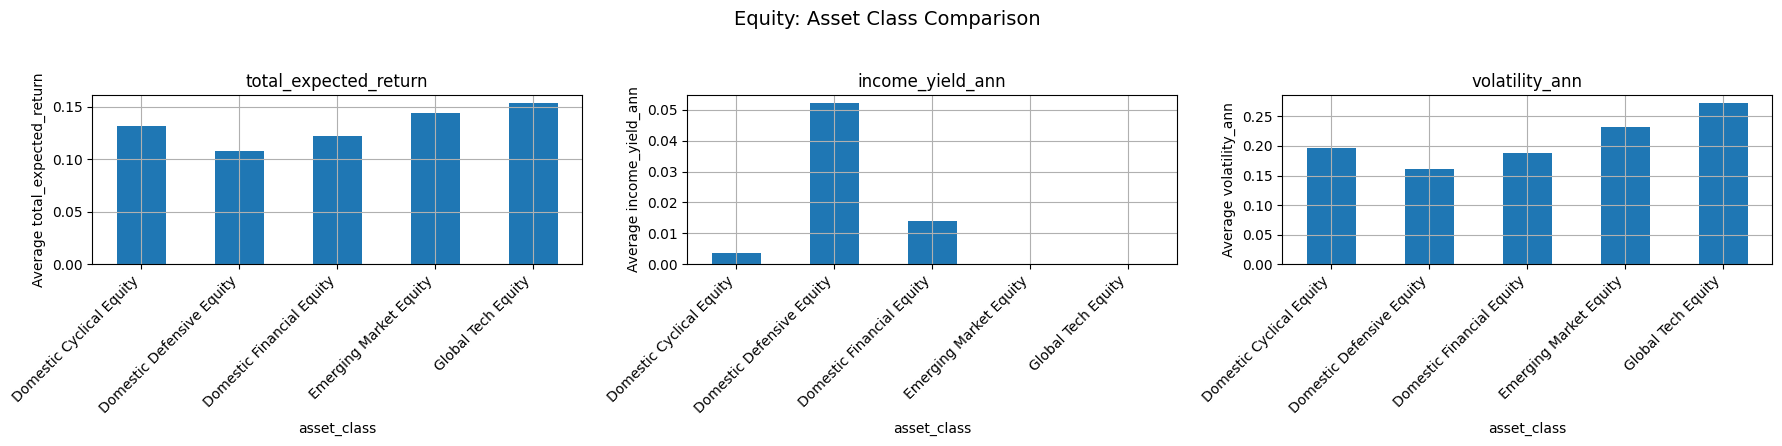

#### Fixed Income

,total_expected_return,income_yield_ann,volatility_ann
asset_class,,,
Corporate Bonds,0.0952,0.0952,0.1025
Long Government Bonds,0.0819,0.0819,0.0960
Short Government Bonds,0.0588,0.0588,0.0300


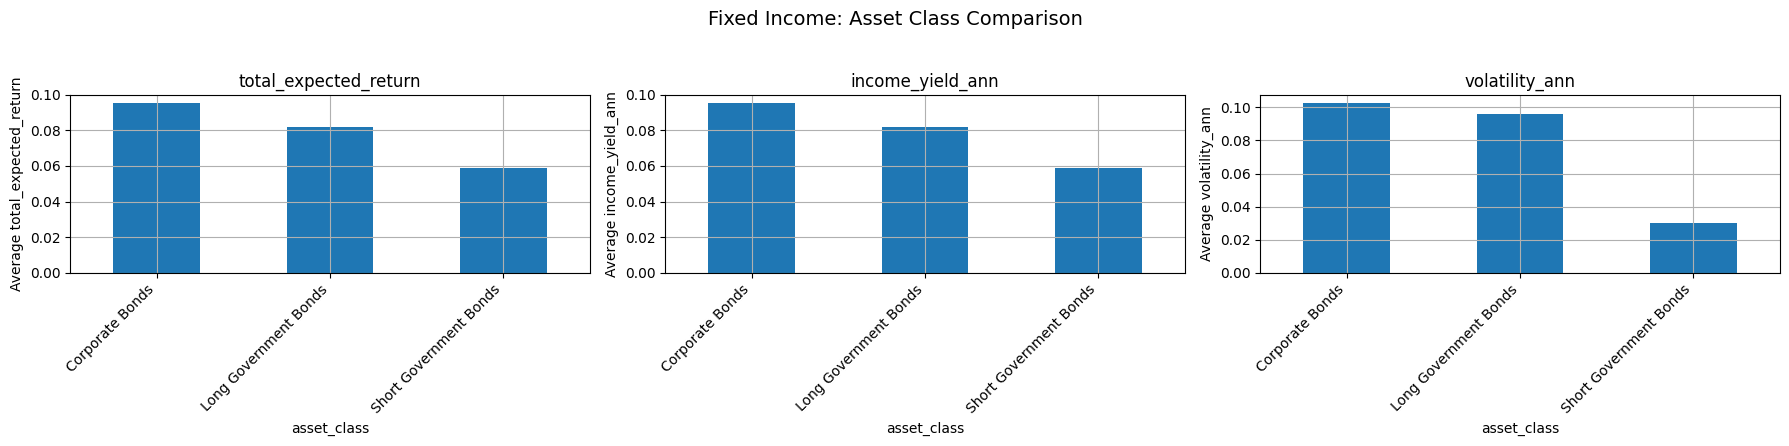

#### Fund

,total_expected_return,income_yield_ann,volatility_ann
asset_class,,,
Alternative Investments,0.1182,0.0252,0.1364
Real Estate Fund,0.1133,0.0724,0.1777


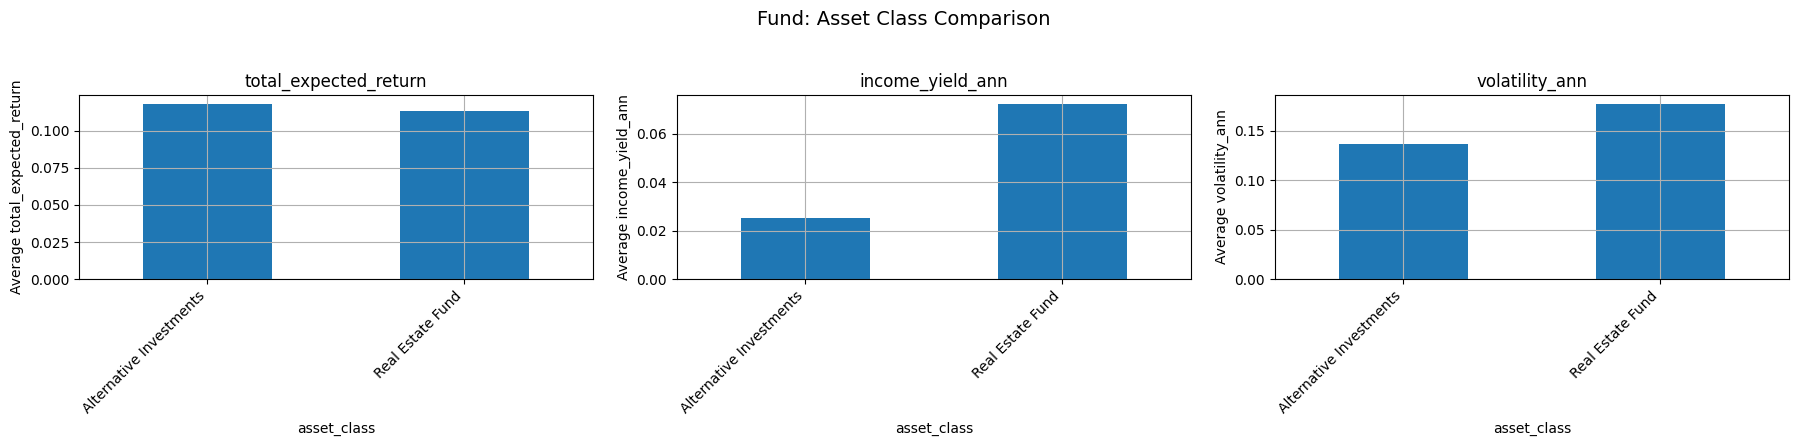

#### Cash

,total_expected_return,income_yield_ann,volatility_ann
asset_class,,,
JMD T-Bill,0.0490,0.0375,0.0123
USD T-Bill,0.0394,0.0394,0.0071


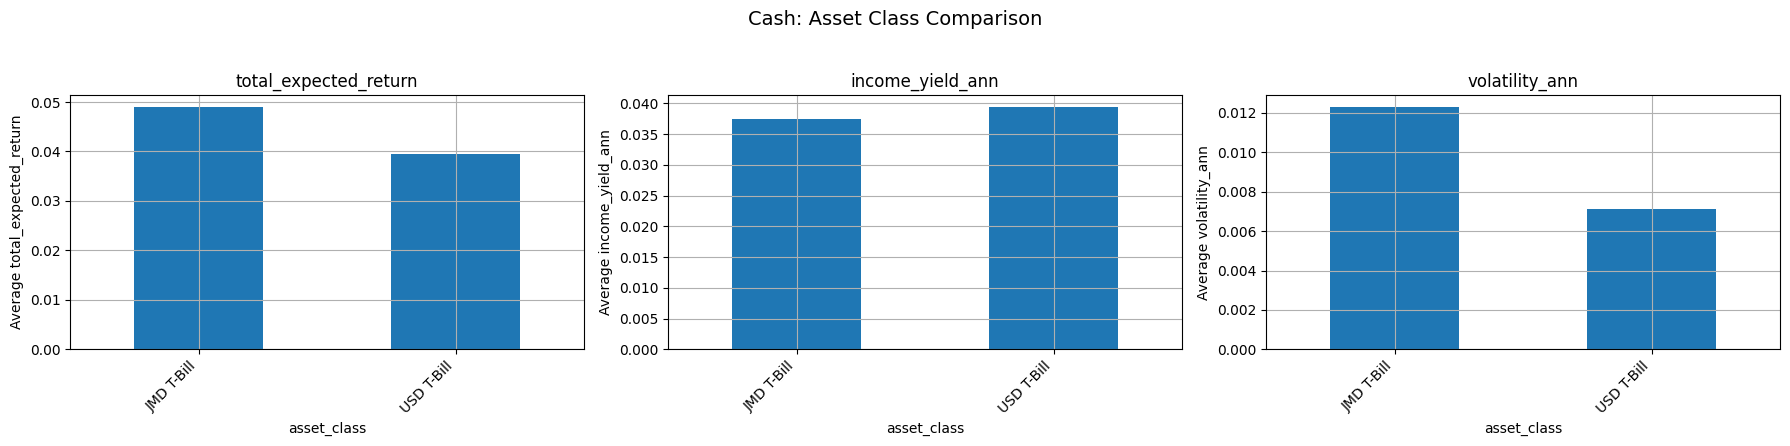

In [ ]:
feature_columns_to_compare = [
    "total_expected_return",
    "income_yield_ann",
    "volatility_ann",
]

super_class_order = full_assets_df["super_class"].drop_duplicates().tolist()

for super_class_name in super_class_order:
    subset_df = (
        full_assets_df.loc[full_assets_df["super_class"] == super_class_name]
        .groupby("asset_class")[feature_columns_to_compare]
        .mean()
    )

    display(Markdown(f"#### {super_class_name}"))
    display(subset_df.round(4))

    fig, axes = plt.subplots(1, len(feature_columns_to_compare), figsize=(18, 4.5))
    if len(feature_columns_to_compare) == 1:
        axes = [axes]

    for ax, feature_name in zip(axes, feature_columns_to_compare):
        subset_df[feature_name].plot(kind="bar", ax=ax, title=feature_name)
        ax.set_xlabel("asset_class")
        ax.set_ylabel(f"Average {feature_name}")
        ax.tick_params(axis="x", rotation=45)
        for label in ax.get_xticklabels():
            label.set_ha("right")

    fig.suptitle(f"{super_class_name}: Asset Class Comparison", fontsize=14)
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


## Step 8: Whole-Dataset Asset Views

The asset universe here is small, so histograms are not the clearest summary.

These plots are easier to read:
- sorted bar charts show exactly which assets are higher or lower
- the scatter plot shows the return-versus-volatility trade-off directly


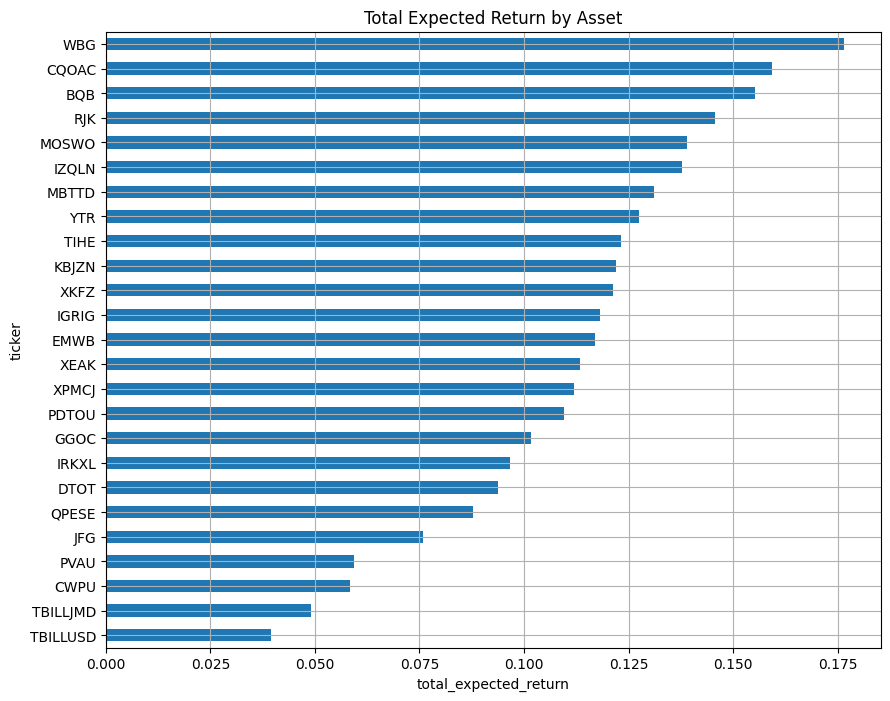

In [ ]:
sorted_return_df = full_assets_df.reset_index()[["ticker", "total_expected_return", "super_class"]].sort_values(
    "total_expected_return"
)

sorted_return_df.plot(
    kind="barh",
    x="ticker",
    y="total_expected_return",
    title="Total Expected Return by Asset",
    legend=False,
    figsize=(10, 8),
)
plt.xlabel("total_expected_return")
plt.ylabel("ticker")
plt.show()


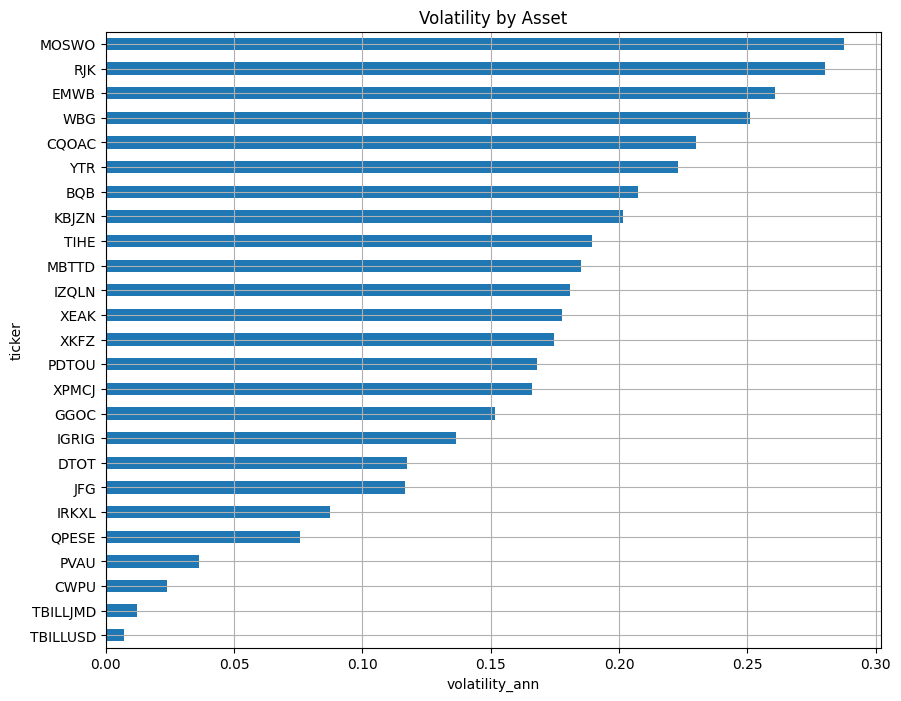

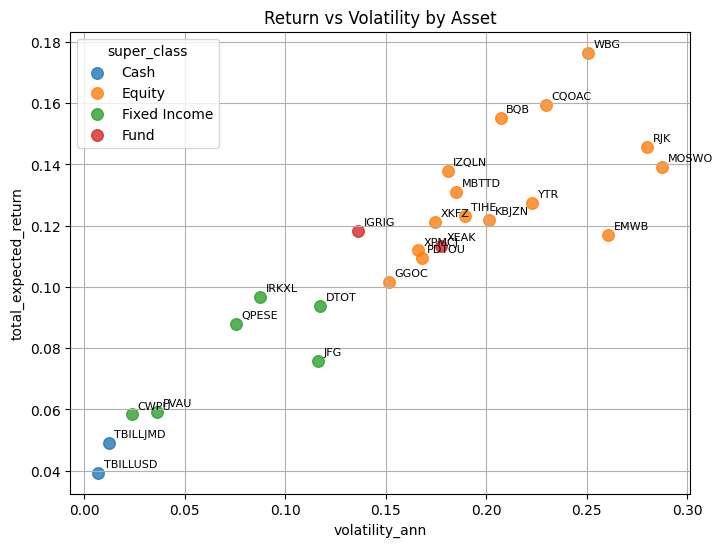

In [ ]:
sorted_volatility_df = full_assets_df.reset_index()[["ticker", "volatility_ann", "super_class"]].sort_values(
    "volatility_ann"
)

sorted_volatility_df.plot(
    kind="barh",
    x="ticker",
    y="volatility_ann",
    title="Volatility by Asset",
    legend=False,
    figsize=(10, 8),
)
plt.xlabel("volatility_ann")
plt.ylabel("ticker")
plt.show()

plt.figure(figsize=(8, 6))
for super_class_name, group in full_assets_df.reset_index().groupby("super_class"):
    plt.scatter(
        group["volatility_ann"],
        group["total_expected_return"],
        label=super_class_name,
        s=70,
        alpha=0.8,
    )

for _, row in full_assets_df.reset_index()[["ticker", "volatility_ann", "total_expected_return"]].iterrows():
    plt.annotate(
        row["ticker"],
        (row["volatility_ann"], row["total_expected_return"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

plt.title("Return vs Volatility by Asset")
plt.xlabel("volatility_ann")
plt.ylabel("total_expected_return")
plt.legend(title="super_class")
plt.show()


In [ ]:
# Try your own analysis below.
# Example ideas:
# full_assets_df[full_assets_df["currency"] == "USD"]
# full_assets_df[["rate_beta", "inflation_beta", "fx_beta"]].describe()


## Step 9: Supplementary Worked Example `CWPU`

This is optional. Keep it at the bottom as a reference example rather than part of the main workflow.


In [ ]:
example_asset_ticker = "CWPU"
example_asset_df = full_assets_df.loc[[example_asset_ticker]].T
example_asset_df.columns = [example_asset_ticker]
example_asset_df


,CWPU
super_class,Fixed Income
asset_class,Short Government Bonds
currency,JMD
total_expected_return,0.0584
income_yield_ann,0.0584
volatility_ann,0.0239
semi_deviation_ann,0.0159
skewness,0.1301
excess_kurtosis,0.3887
modified_duration,1.2713


### How to read the `CWPU` example

- `super_class = Fixed Income` and `asset_class = Short Government Bonds` tell you this is a bond-like fixed-income asset.
- `currency = JMD` tells you the row is expressed in Jamaican dollars.
- `total_expected_return` and `income_yield_ann` are the same here, so the expected return is being driven almost entirely by income.
- `volatility_ann` and `semi_deviation_ann` are both fairly low in this dataset, which is consistent with a lower-volatility fixed-income profile.
- `modified_duration` is positive, so the asset still has some interest-rate sensitivity.
- `fx_beta = 0.0` means this row is not showing currency sensitivity for this example.
